In [1]:
!pip install pyodbc

In [3]:
!pip install mysql-connector-python

In [5]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [7]:
!pip3 install pymysql
!pip3 install ipython-sql
!pip3 install mysqlclient

In [9]:
# Database connection details
db_name = "vehicle_sales_management_system"
db_host = "localhost"
db_username = "root"
db_password = "mihir30@P"

In [11]:
!pip install pymysql

In [12]:
import pymysql

In [14]:
conn = pymysql.connect(
        host=db_host,
        port=3306,
        user=db_username,
        passwd=db_password,
        db=db_name
    )
print("Connection successful!")

Connection successful!


In [17]:
cursor = conn.cursor()
cursor.execute("SHOW TABLES;")
tables = cursor.fetchall()  # Fetch all table names
cursor.close()

In [19]:
table_names = [table[0] for table in tables]
print("Tables found in database:", table_names)

Tables found in database: ['bikes', 'branch', 'cars', 'cash', 'customer', 'insurance', 'loan', 'manufacturer', 'payment', 'reservation', 'salesorder', 'salesperson', 'services', 'trucks', 'vehicle']


In [21]:
tables = [ 'bikes', 'branch', 'cars', 'cash', 'customer', 'insurance', 'loan', 'manufacturer', 'payment', 'reservation', 'salesorder', 'salesperson', 'services', 'trucks', 'vehicle'
]

# Load data from all tables into DataFrames
dataframes = {}
for table in tables:
    try:
        df = pd.read_sql(f"SELECT * FROM {table}", conn)
        dataframes[table.strip('`')] = df
        print(f"Loaded table: {table}")
    except Exception as e:
        print(f"Error loading table {table}: {e}")

Loaded table: bikes
Loaded table: branch
Loaded table: cars
Loaded table: cash
Loaded table: customer
Loaded table: insurance
Loaded table: loan
Loaded table: manufacturer
Loaded table: payment
Loaded table: reservation
Loaded table: salesorder
Loaded table: salesperson
Loaded table: services
Loaded table: trucks
Loaded table: vehicle


Query 1: A histogram showing distribution of vehicle prices 

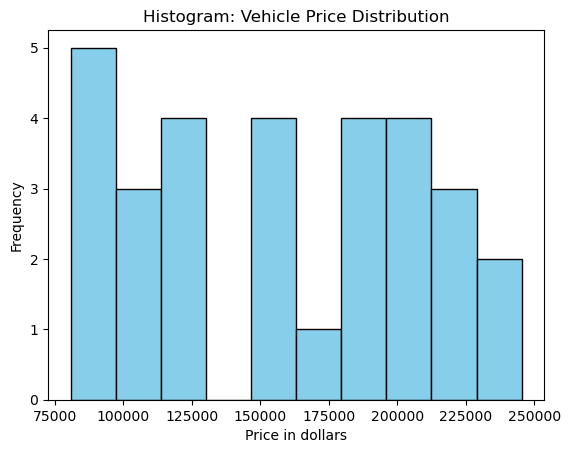

In [24]:
# Query for data
query = """
SELECT v_price FROM vehicle;
"""
data = pd.read_sql(query, conn)

# Histogram
plt.hist(data['v_price'], bins=10, color = 'skyblue', edgecolor='black')
plt.title('Histogram: Vehicle Price Distribution')
plt.xlabel('Price in dollars')
plt.ylabel('Frequency')
plt.show()


The above histogram shows distribution of vehicle prices in dollars. 
The X-axis represents vehicle price ranges while the Y-axis shows how many vehicles are in that price range. 

Query 2: A pie chart representing sales distribution by car model

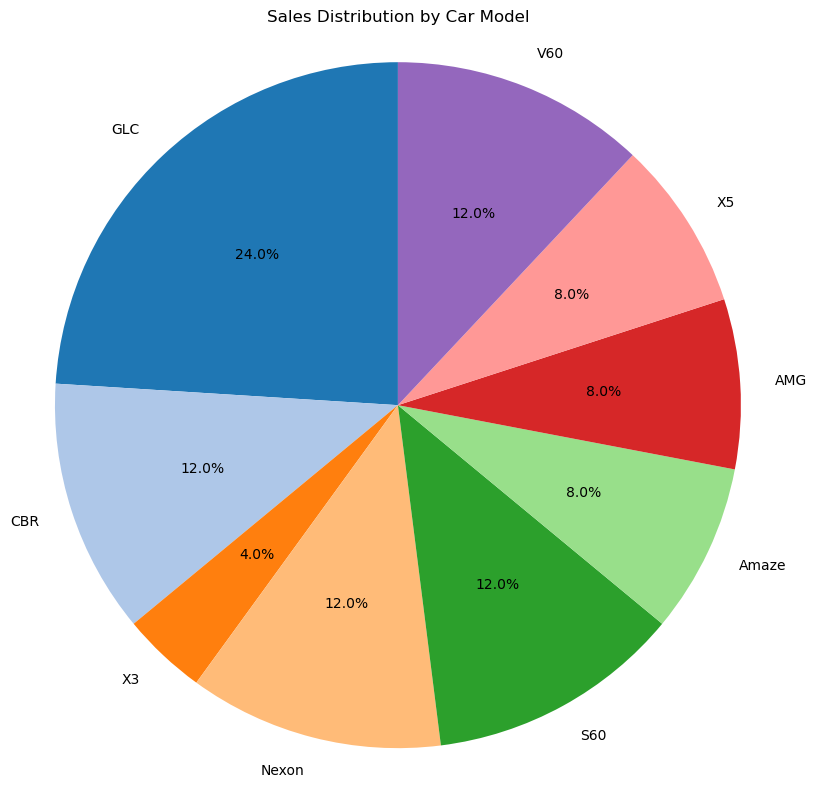

In [28]:
#SQL Query
query = """
SELECT v_model, COUNT(sales_id) AS SalesCount
FROM salesorder so
JOIN vehicle v ON so.vehicle_id = v.vehicle_id
GROUP BY v_model;
"""
data = pd.read_sql(query, conn)

#Pie chart
plt.figure(figsize=(8, 8)) 
plt.pie(
    data['SalesCount'], 
    labels=data['v_model'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=plt.cm.tab20.colors 
)
plt.title('Sales Distribution by Car Model')
plt.axis('equal')
plt.tight_layout()
plt.show()


The above pie chart shows each car model as a slice with the size proportional to its sales. 
The car model GLC has highest 24% sales while X3 have lowest with 4%.

Query 3: A bar chart showing the payment type opted by customers 

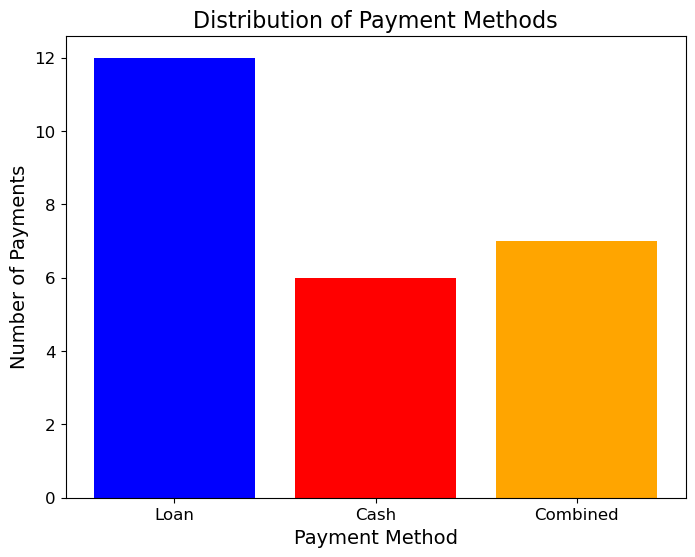

In [32]:
#SQL Query
query = """
SELECT p_method, COUNT(payment_id) AS PaymentCount
FROM payment
GROUP BY p_method;
"""

data = pd.read_sql(query, conn)

# Bar Chart
plt.figure(figsize=(8, 6))
plt.bar(data['p_method'], data['PaymentCount'], color=['blue', 'red', 'orange'])
plt.title('Distribution of Payment Methods', fontsize=16)
plt.xlabel('Payment Method', fontsize=14)
plt.ylabel('Number of Payments', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout
plt.show()

The above bar chart shows how payment was completed while purchasing a vehicle. 


Query 4: A scatter plot visualising vehicle sales price and its manufacturing year.

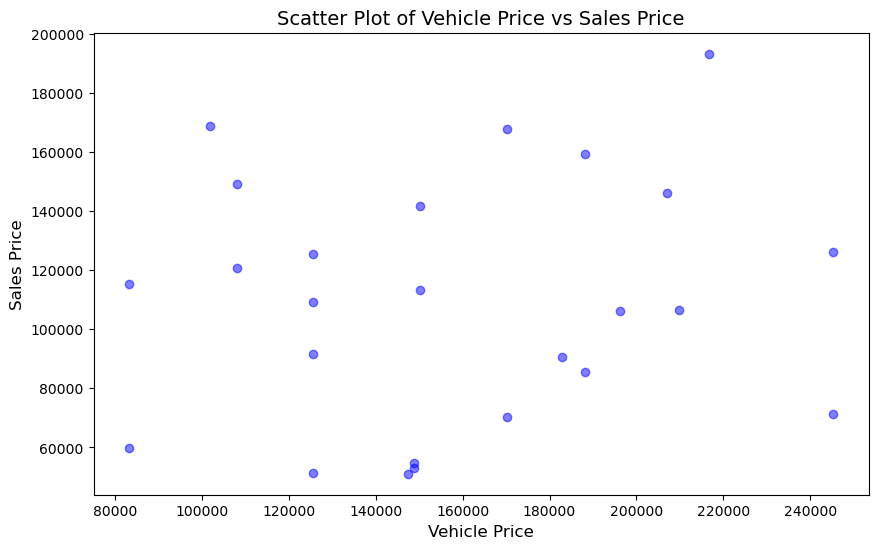

In [51]:
# SQL Query
query = """
SELECT Vehicle.v_price AS vehicle_price, SalesOrder.s_price AS sales_price
FROM Vehicle
INNER JOIN SalesOrder ON Vehicle.vehicle_id = SalesOrder.vehicle_id;
"""

# Fetch data using pandas
df = pd.read_sql(query, conn)


# Scatter Plot of vehicle_price vs sales_price
plt.figure(figsize=(10, 6))
plt.scatter(df['vehicle_price'], df['sales_price'], color='blue', alpha=0.5)

# Adding labels and title
plt.title('Scatter Plot of Vehicle Price vs Sales Price', fontsize=14)
plt.xlabel('Vehicle Price', fontsize=12)
plt.ylabel('Sales Price', fontsize=12)

# Display the plot
plt.show()


This is a scatter plot that visualizes the relationship between the vehicle price and the sales price to identify patterns or correlations in the data.

Query 5: A heatmap to visualize the relationship between SalesOrder, Payment and Customer.

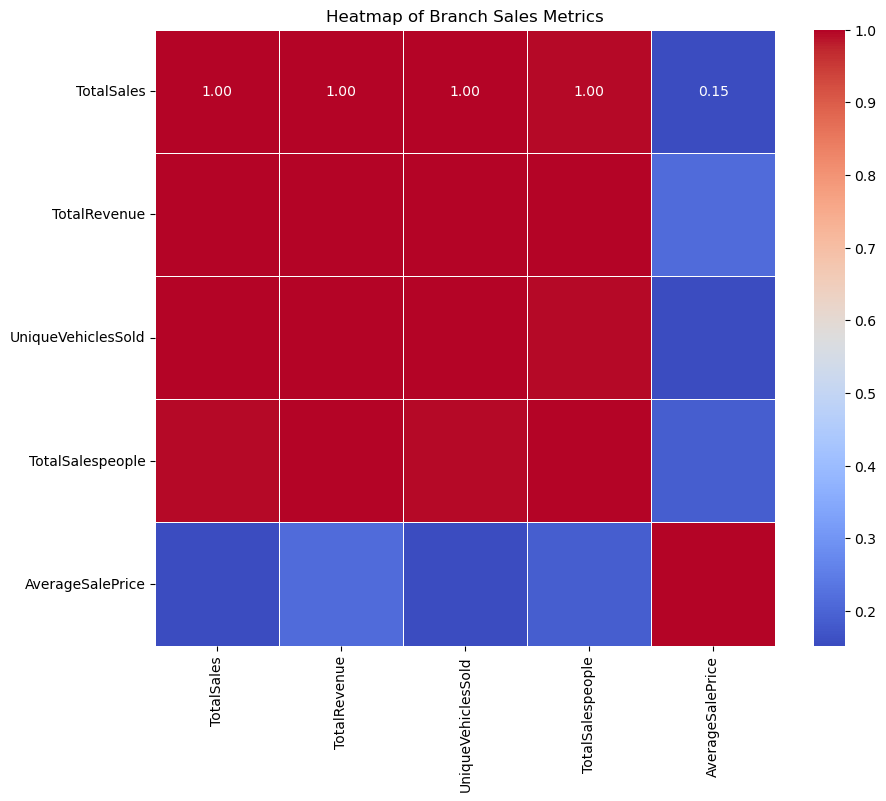

In [69]:
import seaborn as sns
# SQL query

query = """
SELECT 
    Customer.customer_id, 
    Customer.c_name, 
    Payment.p_method, 
    SUM(Payment.p_amount) AS total_payment
FROM SalesOrder
INNER JOIN Customer ON SalesOrder.customer_id = Customer.customer_id
INNER JOIN Payment ON SalesOrder.sales_id = Payment.sales_id
GROUP BY Customer.customer_id, Customer.c_name, Payment.p_method;
"""

# Fetch data
data = pd.read_sql(query, conn)


plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Branch Sales Metrics")
plt.tight_layout
plt.show()



The above heatmap shows the total payment amount for each customer and payment method combination.

Query 6:  A horizontal bar chart showing total sales generated by each salesperson

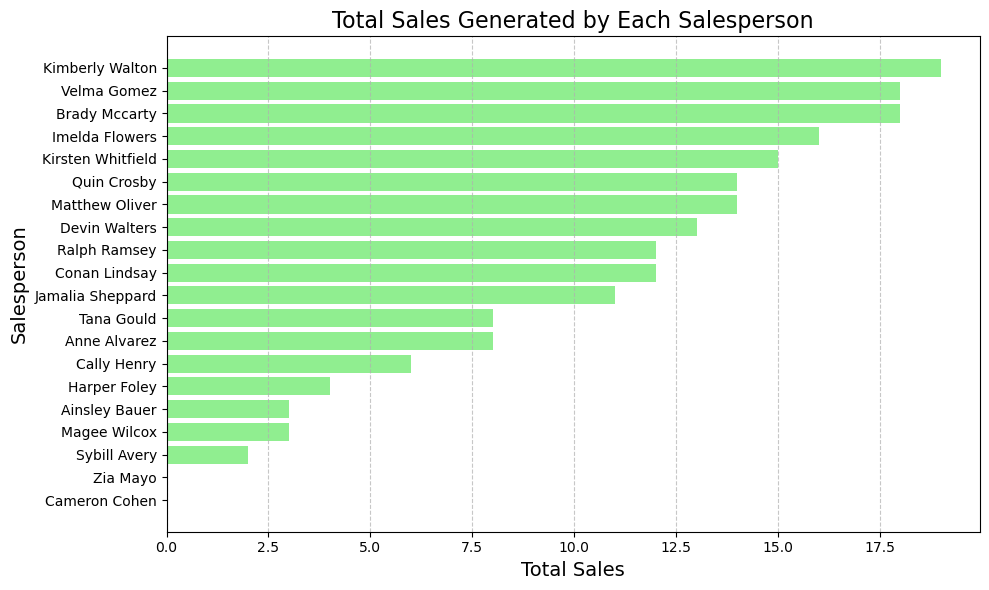

In [46]:
# SQL Query
query = """
SELECT sp_name, total_sales AS TotalSales
FROM salesperson
ORDER BY TotalSales DESC;
"""
data = pd.read_sql(query, conn)

# Horizontal Bar Chart
plt.figure(figsize=(10, 6))
plt.barh(data['sp_name'], data['TotalSales'], color='lightgreen')
plt.title('Total Sales Generated by Each Salesperson', fontsize=16)
plt.xlabel('Total Sales', fontsize=14)
plt.ylabel('Salesperson', fontsize=14)
plt.gca().invert_yaxis()  # Optional: Invert y-axis for descending order
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Add grid for readability
plt.tight_layout()
plt.show()


The above horizontal bar chart shows total sales generated by each salesperson. 
Justina and Inez has generated the highest total sales by selling 25 vehicles each while Wyatt and Athena has only sold 2 vehicles each. 